# UAV Battery Tool — Analysis Configurator

Run this notebook first. Select your UAV, mission, temperature, and batteries, then save.
All other notebooks will load these settings automatically from `analysis_config.json`.

In [1]:
import sys, os, json
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings; warnings.filterwarnings('ignore')

from batteries.database import BatteryDatabase

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10, 'axes.grid': True, 'grid.alpha': 0.25})
DB_PATH   = '../battery_db.xlsx'
CFG_PATH  = 'analysis_config.json'
db = BatteryDatabase(DB_PATH).load()
print(db.summary())

═══ Battery Database Summary ═══
  Chemistries       : 9
  Cells             : 11
  Battery packs     : 8
  Discharge points  : 132
  Equipment items   : 29
  UAV configurations: 3
  Mission profiles  : 3


## 1 · UAV Selection

In [2]:
print('Available UAV configurations:\n')
uav_rows = []
for uid, uav in db.uav_configs.items():
    total_w  = sum(e.weight_g * q for e, q in uav.equipment_list)
    hover_w  = sum(e.hover_power_w * q for e, q in uav.equipment_list)
    cruise_w = sum(e.cruise_power_w * q for e, q in uav.equipment_list)
    uav_rows.append({
        'UAV_ID':        uid,
        'Equipment items': len(uav.equipment_list),
        'Total weight (g)': round(total_w, 0),
        'Hover power (W)':  round(hover_w, 0),
        'Cruise power (W)': round(cruise_w, 0),
    })
df_uav = pd.DataFrame(uav_rows)
print(df_uav.to_string(index=False))

print('\nEquipment detail per UAV:')
for uid, uav in db.uav_configs.items():
    print(f'  {uid}:')
    for equip, qty in uav.equipment_list:
        print(f'    x{qty}  {equip.equip_id:<30}  {equip.category}')

Available UAV configurations:

        UAV_ID  Equipment items  Total weight (g)  Hover power (W)  Cruise power (W)
HEX_SURVEY_900               11            3073.0            368.0             308.0
   HEX_AG_1200               10            4690.0            636.0             516.0
  QUAD_INSPECT               10            1492.0            169.0             141.0

Equipment detail per UAV:
  HEX_SURVEY_900:
    x6  MOT_T_MOTOR_MN4014              Propulsion
    x6  ESC_FLAME_60A                   Propulsion
    x1  FC_PIXHAWK_6C                   Avionics
    x1  GPS_HERE3                       Avionics
    x1  CAM_RGB_10MP                    Payload
    x1  GIMBAL_3AXIS                    Payload
    x1  RC_CROSSFIRE                    Communication
    x1  TELEMETRY_900MHZ                Communication
    x1  POWER_MODULE_60A                Power Systems
    x1  BMS_ACTIVE                      Power Systems
    x1  FRAME_HEX_900                   Frame/Structure
  HEX_AG_1200:
 

In [3]:
UAV_ID = 'HEX_SURVEY_900'      # <── change this

# Optional: override specific equipment quantities.
# Format: {equip_id: quantity}  — items not listed keep their preset qty.
# Example: CUSTOM_EQUIPMENT = {'MOT_T_MOTOR_MN601S': 8, 'CAM_SONY_A7R': 0}
CUSTOM_EQUIPMENT = {}

# ─────────────────────────────────────────────────────────────────────────────
if UAV_ID not in db.uav_configs:
    raise ValueError(f'UAV_ID "{UAV_ID}" not found. Choose from: {list(db.uav_configs)}')

uav = db.uav_configs[UAV_ID]
print(f'Selected: {UAV_ID}')
print(f'  Equipment:')
equip_list = []
for equip, qty in uav.equipment_list:
    eid = equip.equip_id
    q   = CUSTOM_EQUIPMENT.get(eid, qty)
    if q > 0:
        print(f'    x{q}  {eid:<35} hover={equip.hover_power_w*q:.0f}W  cruise={equip.cruise_power_w*q:.0f}W')
        equip_list.append({'equip_id': eid, 'qty': q})

hover_total  = sum(db.equipment[e['equip_id']].hover_power_w  * e['qty'] for e in equip_list)
cruise_total = sum(db.equipment[e['equip_id']].cruise_power_w * e['qty'] for e in equip_list)
print(f'  Total hover power : {hover_total:.0f} W')
print(f'  Total cruise power: {cruise_total:.0f} W')

Selected: HEX_SURVEY_900
  Equipment:
    x6  MOT_T_MOTOR_MN4014                  hover=330W  cruise=270W
    x6  ESC_FLAME_60A                       hover=18W  cruise=18W
    x1  FC_PIXHAWK_6C                       hover=4W  cruise=4W
    x1  GPS_HERE3                           hover=0W  cruise=0W
    x1  CAM_RGB_10MP                        hover=2W  cruise=2W
    x1  GIMBAL_3AXIS                        hover=6W  cruise=6W
    x1  RC_CROSSFIRE                        hover=1W  cruise=1W
    x1  TELEMETRY_900MHZ                    hover=1W  cruise=1W
    x1  POWER_MODULE_60A                    hover=2W  cruise=2W
    x1  BMS_ACTIVE                          hover=2W  cruise=2W
    x1  FRAME_HEX_900                       hover=0W  cruise=0W
  Total hover power : 368 W
  Total cruise power: 308 W


## 2 · Mission Profile Selection

In [4]:
print('Available mission profiles:\n')
mission_rows = []
for mid, m in db.missions.items():
    total_s   = sum(ph.duration_s for ph in m.phases)
    total_km  = sum(getattr(ph, 'distance_m', 0) or 0 for ph in m.phases) / 1000
    phases    = ', '.join(ph.phase_type for ph in m.phases)
    mission_rows.append({
        'Mission_ID':    mid,
        'Duration (s)':  int(total_s),
        'Distance (km)': round(total_km, 1),
        'Phase sequence': phases,
    })
df_missions = pd.DataFrame(mission_rows)
print(df_missions.to_string(index=False))

print('\nPhase detail per mission:')
for mid, m in db.missions.items():
    print(f'  {mid}:')
    for ph in m.phases:
        pw = getattr(ph, 'power_override_w', None)
        print(f'    [{ph.phase_type:<12}] {ph.duration_s:>5}s  '
              f'dist={getattr(ph,"distance_m",0) or 0:>6.0f}m  '
              f'{("power_override="+str(pw)+"W") if pw else ""}')

Available mission profiles:

 Mission_ID  Duration (s)  Distance (km)                                                     Phase sequence
 SURVEY_STD          1470            6.7         IDLE, TAKEOFF, CLIMB, CRUISE, HOVER, CRUISE, DESCEND, LAND
   AG_SPRAY          1110            2.6 IDLE, TAKEOFF, CRUISE, CRUISE, HOVER, CRUISE, CRUISE, CRUISE, LAND
INSPECT_STD           850            0.3          IDLE, TAKEOFF, CLIMB, HOVER, CRUISE, HOVER, DESCEND, LAND

Phase detail per mission:
  SURVEY_STD:
    [IDLE        ]  60.0s  dist=     0m  
    [TAKEOFF     ]  30.0s  dist=     0m  
    [CLIMB       ]  60.0s  dist=   200m  
    [CRUISE      ] 900.0s  dist=  4500m  
    [HOVER       ]  30.0s  dist=     0m  
    [CRUISE      ] 300.0s  dist=  2000m  
    [DESCEND     ]  60.0s  dist=     0m  
    [LAND        ]  30.0s  dist=     0m  
  AG_SPRAY:
    [IDLE        ]  90.0s  dist=     0m  
    [TAKEOFF     ]  20.0s  dist=     0m  
    [CRUISE      ] 120.0s  dist=   600m  
    [CRUISE      ] 240.0

Selected: SURVEY_STD  (1470.0s / 24.5 min)


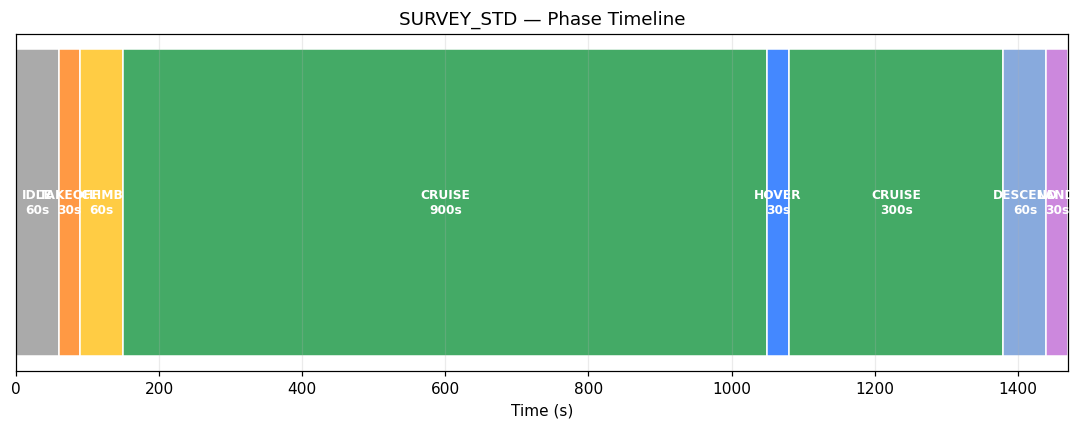

In [5]:
# ── SELECT YOUR MISSION ──────────────────────────────────────────────────────
MISSION_ID = 'SURVEY_STD'      # <── change this

# ─────────────────────────────────────────────────────────────────────────────
if MISSION_ID not in db.missions:
    raise ValueError(f'MISSION_ID "{MISSION_ID}" not found. Choose from: {list(db.missions)}')

mission = db.missions[MISSION_ID]
total_s = sum(ph.duration_s for ph in mission.phases)
print(f'Selected: {MISSION_ID}  ({total_s}s / {total_s/60:.1f} min)')

# Power profile bar chart
fig, ax = plt.subplots(figsize=(10, 4))
PHASE_COLORS = {
    'IDLE':            '#AAAAAA',  # ground idle
    'TAKEOFF':         '#FF9944',  # full power lift-off
    'CLIMB':           '#FFCC44',  # powered climb
    'CRUISE':          '#44AA66',  # level cruise
    'HOVER':           '#4488FF',  # stationary hover
    'DESCEND':         '#88AADD',  # descent
    'LAND':            '#CC88DD',  # landing
    'PAYLOAD_OPS':     '#FF6688',  # payload operations
    'EMERGENCY':       '#FF2222',  # emergency
    # ── Fixed-wing VTOL phases ────────────────────────────────────────────
    'VTOL_TRANSITION': '#FF6611',  # lift+thrust overlap during transition
    'VTOL_HOVER':      '#22AAFF',  # explicit multirotor hover
    'FW_CRUISE':       '#00CC77',  # efficient fixed-wing cruise
    'FW_CLIMB':        '#AACC44',  # fixed-wing climb
    'FW_DESCEND':      '#99CCEE',  # glide descent
}
x_pos = 0
for ph in mission.phases:
    color = PHASE_COLORS.get(ph.phase_type, '#CCC')
    ax.barh(0, ph.duration_s, left=x_pos, height=0.6, color=color, edgecolor='white')
    ax.text(x_pos + ph.duration_s/2, 0, ph.phase_type + chr(10) + str(int(ph.duration_s)) + 's',
            ha='center', va='center', fontsize=8, fontweight='bold', color='white')
    x_pos += ph.duration_s
ax.set_xlim(0, x_pos); ax.set_yticks([])
ax.set_xlabel('Time (s)'); ax.set_title(f'{MISSION_ID} — Phase Timeline')
plt.tight_layout(); plt.show()

## 3 · Temperature Configuration

Primary temperature   : 25.0°C
Temperature sweep     : [-10, -5, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45]


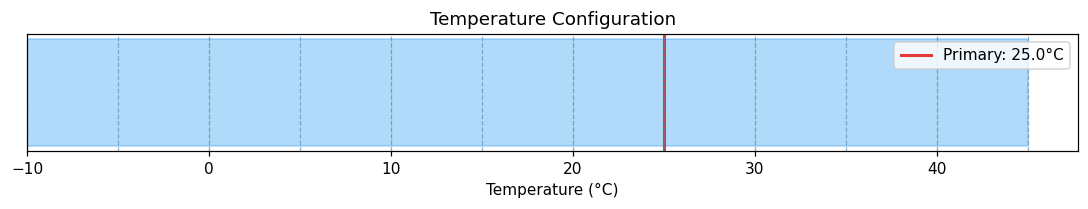

In [6]:
# ── SET TEMPERATURE ───────────────────────────────────────────────────────────
# For a single analysis temperature:
AMBIENT_TEMP_C = 25.0          # <── change this

# For a temperature sweep (used in Notebook 03 and the scorecard):
# Leave TEMP_SWEEP_RANGE as None to use AMBIENT_TEMP_C only.
# Or set to (min, max, step) to sweep a range.
TEMP_SWEEP_RANGE = (-10, 45, 5)   # (min_C, max_C, step_C) — or None

# ─────────────────────────────────────────────────────────────────────────────
if TEMP_SWEEP_RANGE:
    t_min, t_max, t_step = TEMP_SWEEP_RANGE
    TEMP_SWEEP = list(range(int(t_min), int(t_max) + 1, int(t_step)))
else:
    TEMP_SWEEP = [AMBIENT_TEMP_C]

print(f'Primary temperature   : {AMBIENT_TEMP_C}°C')
print(f'Temperature sweep     : {TEMP_SWEEP}')

# Visual summary
fig, ax = plt.subplots(figsize=(10, 2))
ax.barh(0, max(TEMP_SWEEP) - min(TEMP_SWEEP), left=min(TEMP_SWEEP),
        height=0.5, color='#2196F3', alpha=0.35, edgecolor='#2196F3')
ax.axvline(AMBIENT_TEMP_C, color='#E53935', linewidth=2, label=f'Primary: {AMBIENT_TEMP_C}°C')
for t in TEMP_SWEEP:
    ax.axvline(t, color='steelblue', linewidth=0.8, linestyle='--', alpha=0.6)
ax.set_xlabel('Temperature (°C)'); ax.set_yticks([])
ax.set_title('Temperature Configuration'); ax.legend()
plt.tight_layout(); plt.show()

## 4 · Battery Selection

In [7]:
print('Battery catalogue:\n')
batt_rows = []
for bid, p in db.packs.items():
    batt_rows.append({
        'Battery_ID':      bid,
        'Chemistry':       p.chemistry_id,
        'Config':          f'{p.cells_series}S{p.cells_parallel}P',
        'Voltage (V)':     round(p.pack_voltage_nom, 1),
        'Capacity (Ah)':   round(p.pack_capacity_ah, 1),
        'Energy (Wh)':     round(p.pack_energy_wh, 1),
        'Weight (g)':      round(p.pack_weight_g, 0),
        'IR (mΩ)':         round(p.internal_resistance_mohm, 1),
        'Max cont. (A)':   round(p.max_cont_discharge_a, 0),
        'UAV class':       getattr(p, 'uav_class', ''),
    })
df_batt = pd.DataFrame(batt_rows)
print(df_batt.to_string(index=False))

Battery catalogue:

    Battery_ID Chemistry Config  Voltage (V)  Capacity (Ah)  Energy (Wh)  Weight (g)  IR (mΩ)  Max cont. (A)       UAV class
  BAT_FPV_4S1P      LIPO   4S1P         14.8            1.3         19.2       128.0     15.0           65.0    FPV / Racing
  BAT_MICRO_1S      LIHV   1S1P          3.9            0.6          2.1        14.0     30.0            5.0       Micro UAV
  BAT_MID_6S2P    LION21   6S2P         21.9            9.0        197.0       840.0     28.0           90.0  Inspection UAV
  BAT_MID_6S4P    LION21   6S4P         21.8           20.0        436.0      1692.0     88.0           56.0  Long Endurance
   BAT_AG_6S1P   LIFEPO4   6S1P         19.2           10.0        192.0      1860.0      5.0           30.0 Agriculture UAV
BAT_HLIFT_6S2P   LIFEPO4   6S2P         19.8            5.0         99.0       912.0     16.0          140.0  Heavy Lift UAV
  BAT_LE_12S2P    LION21  12S2P         43.8            8.0        350.0      1656.0     36.0           7

Batteries selected for analysis (8):
  BAT_FPV_4S1P                   LIPO       19 Wh  128 g
  BAT_MICRO_1S                   LIHV       2 Wh  14 g
  BAT_MID_6S2P                   LION21     197 Wh  840 g
  BAT_MID_6S4P                   LION21     436 Wh  1692 g
  BAT_AG_6S1P                    LIFEPO4    192 Wh  1860 g
  BAT_HLIFT_6S2P                 LIFEPO4    99 Wh  912 g
  BAT_LE_12S2P                   LION21     350 Wh  1656 g
  BAT_SSS_6S1P                   SSS        111 Wh  606 g


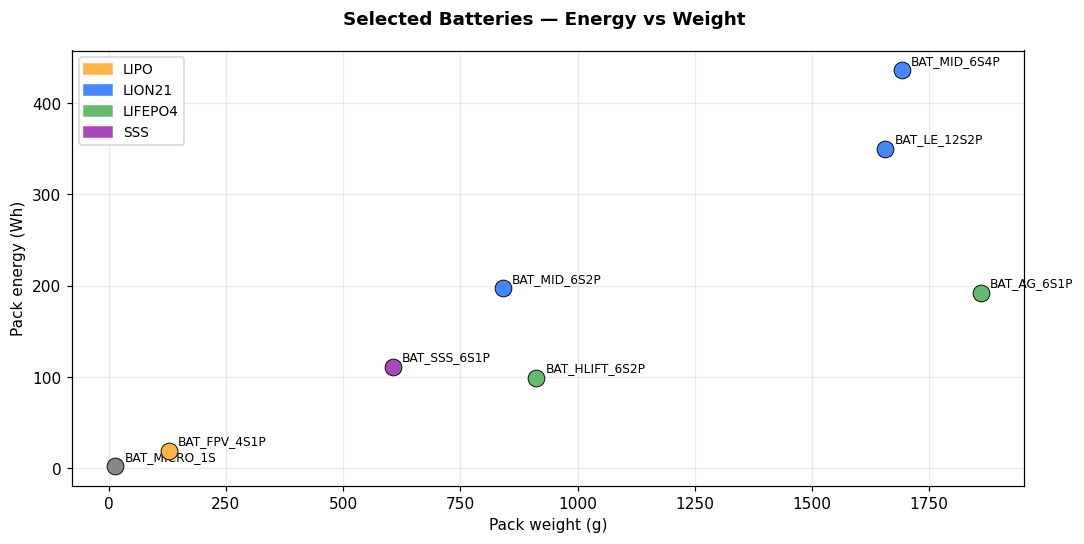

In [8]:
# ── SELECT BATTERIES TO ANALYSE ───────────────────────────────────────────────
# List Battery_IDs from above. Use 'ALL' to include every pack in the catalogue.

SELECTED_BATTERIES = 'ALL'    # <── change to e.g. ['BAT_MID_6S2P', 'BAT_MID_6S4P']

# ─────────────────────────────────────────────────────────────────────────────
if SELECTED_BATTERIES == 'ALL':
    selected_ids = list(db.packs.keys())
else:
    missing = [b for b in SELECTED_BATTERIES if b not in db.packs]
    if missing:
        raise ValueError(f'Unknown battery IDs: {missing}')
    selected_ids = list(SELECTED_BATTERIES)

selected_packs = {bid: db.packs[bid] for bid in selected_ids}
print(f'Batteries selected for analysis ({len(selected_ids)}):')
for bid in selected_ids:
    p = db.packs[bid]
    print(f'  {bid:<30} {p.chemistry_id:<10} {p.pack_energy_wh:.0f} Wh  {p.pack_weight_g:.0f} g')

# Energy vs weight comparison chart
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Selected Batteries — Energy vs Weight', fontweight='bold')
chem_colors = {'LIPO':'#FFB347','LION21':'#4488FF','LIFEPO4':'#66BB6A',
               'SSS':'#AB47BC','LITO':'#26C6DA','LION':'#FF7043'}
for bid in selected_ids:
    p = db.packs[bid]
    color = chem_colors.get(p.chemistry_id, '#888')
    ax.scatter(p.pack_weight_g, p.pack_energy_wh, s=120, color=color,
               edgecolors='black', linewidths=0.6, zorder=4)
    ax.annotate(bid, (p.pack_weight_g, p.pack_energy_wh),
                textcoords='offset points', xytext=(6, 4), fontsize=8)
ax.set_xlabel('Pack weight (g)'); ax.set_ylabel('Pack energy (Wh)')
patches = [mpatches.Patch(color=c, label=k) for k, c in chem_colors.items()
           if any(db.packs[b].chemistry_id == k for b in selected_ids)]
ax.legend(handles=patches, fontsize=9)
plt.tight_layout(); plt.show()

## 4b · Multi-Battery Combination (optional)

Combine multiple identical packs into a single virtual pack for analysis.

- **Series**: voltages add, capacity stays the same (higher voltage)
- **Parallel**: capacities add, voltage stays the same (more energy/runtime)

Leave `BATTERY_COMBINATION = None` to skip and analyse packs individually.


In [9]:
from batteries.builder import combine_packs

# ── MULTI-BATTERY COMBINATION ──────────────────────────────────────────────────
# Set to None to analyse packs individually (default).
# Or specify packs and topology to create a combined virtual pack.
#
# Examples:
#   BATTERY_COMBINATION = {'packs': ['BAT_MID_6S2P', 'BAT_MID_6S2P'], 'topology': 'series'}
#   BATTERY_COMBINATION = {'packs': ['BAT_MID_6S4P', 'BAT_MID_6S4P'], 'topology': 'parallel'}

BATTERY_COMBINATION = None   # <── change to dict to combine, or leave None

# ─────────────────────────────────────────────────────────────────────────────
COMBINED_PACK = None
combined_pack_id = None

if BATTERY_COMBINATION is not None:
    combo_ids = BATTERY_COMBINATION.get('packs', [])
    topology  = BATTERY_COMBINATION.get('topology', 'series').lower()
    missing   = [b for b in combo_ids if b not in db.packs]
    if missing:
        raise ValueError(f'Unknown battery IDs in combination: {missing}')
    if len(combo_ids) < 2:
        raise ValueError('BATTERY_COMBINATION requires at least 2 pack IDs')

    src_packs = [db.packs[bid] for bid in combo_ids]
    COMBINED_PACK = combine_packs(src_packs, topology=topology)
    combined_pack_id = COMBINED_PACK.battery_id

    print(f'\nCombined pack ({topology.upper()}):')
    print(f'  ID           : {COMBINED_PACK.battery_id}')
    print(f'  Voltage nom  : {COMBINED_PACK.pack_voltage_nom:.1f} V')
    print(f'  Capacity     : {COMBINED_PACK.pack_capacity_ah:.2f} Ah')
    print(f'  Energy       : {COMBINED_PACK.pack_energy_wh:.0f} Wh')
    print(f'  Max I cont   : {COMBINED_PACK.max_cont_discharge_a:.1f} A')
    print(f'  IR           : {COMBINED_PACK.internal_resistance_mohm:.2f} m\u03a9')
    print(f'  Weight       : {COMBINED_PACK.pack_weight_g:.0f} g')

    # Add to selected_ids if not already present
    if combined_pack_id not in selected_ids:
        selected_ids.append(combined_pack_id)
    # Register in db.packs so all notebooks can use it
    db.packs[combined_pack_id] = COMBINED_PACK
else:
    print('No multi-battery combination configured.')


No multi-battery combination configured.


## 5 · Save Configuration

In [10]:
config = {
    'uav_id':             UAV_ID,
    'custom_equipment':   CUSTOM_EQUIPMENT,
    'mission_id':         MISSION_ID,
    'ambient_temp_c':     AMBIENT_TEMP_C,
    'temp_sweep':         TEMP_SWEEP,
    'selected_batteries': selected_ids,
    'battery_combination': BATTERY_COMBINATION,
    'combined_pack_id':    combined_pack_id,
}

with open(CFG_PATH, 'w') as f:
    json.dump(config, f, indent=2)

print(f'Configuration saved to {CFG_PATH}')
print()
print('═' * 50)
print('  UAV            :', UAV_ID)
print('  Mission        :', MISSION_ID)
print('  Temperature    :', AMBIENT_TEMP_C, '°C')
print('  Temp sweep     :', TEMP_SWEEP)
print('  Batteries      :', selected_ids)
print('═' * 50)
print()
print('You can now run Notebooks 01–05.')
print('They will load this config automatically.')

Configuration saved to analysis_config.json

══════════════════════════════════════════════════
  UAV            : HEX_SURVEY_900
  Mission        : SURVEY_STD
  Temperature    : 25.0 °C
  Temp sweep     : [-10, -5, 0, 5, 10, 15, 20, 25, 30, 35, 40, 45]
  Batteries      : ['BAT_FPV_4S1P', 'BAT_MICRO_1S', 'BAT_MID_6S2P', 'BAT_MID_6S4P', 'BAT_AG_6S1P', 'BAT_HLIFT_6S2P', 'BAT_LE_12S2P', 'BAT_SSS_6S1P']
══════════════════════════════════════════════════

You can now run Notebooks 01–05.
They will load this config automatically.


---
## How other notebooks use this config

Add the following snippet near the top of any notebook to load your settings:

```python
import json, os
CFG_PATH = 'analysis_config.json'
if os.path.exists(CFG_PATH):
    with open(CFG_PATH) as f:
        cfg = json.load(f)
    UAV_ID             = cfg.get('uav_id', 'HEX_SURVEY_900')
    MISSION_ID         = cfg.get('mission_id', 'SURVEY_STD')
    AMBIENT_TEMP_C     = cfg.get('ambient_temp_c', 25.0)
    TEMP_SWEEP         = cfg.get('temp_sweep', [25])
    SELECTED_BATTERIES = cfg.get('selected_batteries', list(db.packs.keys()))
    print('Loaded config from', CFG_PATH)
else:
    print('No config found — using defaults')
```